## Тест модуля восстановления глубины

#### Импортирование общих библиотек и OPR

In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
import sys
sys.path.append('/home/docker_opr_ros2/ros2_ws/src')

In [55]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from cv2 import imread
from skimage.transform import resize
from scipy.spatial.transform import Rotation

In [56]:
import sys
sys.path.append('/home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/Depth-Anything-V2/')  # локальный путь до кода

import cv2
import torch
import os
import pandas as pd
import numpy as np
import random
import os
import gc
import time
import open3d
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import transformers
import cv2.aruco as aruco
import torch.nn.functional as F

from copy import deepcopy
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from accelerate import DistributedDataParallelKwargs, Accelerator, notebook_launcher
from accelerate.utils import set_seed
from tqdm import tqdm
from PIL import Image

import sys
sys.path.append('/home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/Depth-Anything-V2')

from depth_anything_v2.dpt import DepthAnythingV2
from metric_depth.depth_anything_v2.dpt import DepthAnythingV2 as DepthAnythingV2Metric
from metric_depth.dataset.transform import Resize, NormalizeImage, PrepareForNet, Crop
from metric_depth.util.loss import SiLogLoss

In [57]:
from opr.pipelines.depth_estimation import DepthEstimationPipeline

#### Задание нейросети восстановления глубины

Загрузка чекпоинтов:

In [58]:
!mkdir -p /home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/AdelaiDepth/weights/
# !wget -O /home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/AdelaiDepth/weights/res50.pth https://huggingface.co/ffranchina/LeReS/resolve/main/res50.pth

In [59]:
sys.path.append('/home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/AdelaiDepth/LeReS/Minist_Test')
from lib.multi_depth_model_woauxi import RelDepthModel
from lib.net_tools import load_ckpt

def parse_args(a):
    parser = argparse.ArgumentParser(
        description='Configs for LeReS')
    parser.add_argument('--load_ckpt', default='./res50.pth', help='Checkpoint path to load')
    parser.add_argument('--backbone', default='resnext101', help='Checkpoint path to load')

    args = parser.parse_args(a)
    return args

import argparse
arguments = "--load_ckpt /home/docker_opr/OpenPlaceRecognition/third_party/AdelaiDepth/weights/res50.pth \
            --backbone resnet50".split()
args = parse_args(arguments)

old_model = RelDepthModel(backbone='resnet50').cuda()
load_ckpt(args, old_model, None, None)

#### Dataset download

You can download the dataset:

- Kaggle:
  - [ITLP Campus Indoor](https://www.kaggle.com/datasets/alexandermelekhin/itlp-campus-indoor)
  - [ITLP Campus Outdoor](https://www.kaggle.com/datasets/alexandermelekhin/itlp-campus-outdoor)
- Hugging Face:
  - [ITLP Campus Indoor](https://huggingface.co/datasets/OPR-Project/ITLP-Campus-Indoor)
  - [ITLP Campus Outdoor](https://huggingface.co/datasets/OPR-Project/ITLP-Campus-Outdoor)


In [60]:
MODELS_BASE_PATH = '/home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/Depth-Anything-V2/weights'
#DATA_BASE_PATH = '/home/docker_opr/Datasets/OpenPlaceRecognition/itlp_campus_indoor/00_2023-10-25-night/floor_5'
DATA_BASE_PATH = '/home/docker_opr_ros2/Datasets/ITLP_Campus/itlp_campus_outdoor/03_2023-04-11/'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [61]:
from typing import Tuple

def project_points_to_camera(
    points: np.ndarray, proj_matrix: np.ndarray, cam_res: Tuple[int, int]
) -> Tuple[np.ndarray, np.ndarray]:
    if points.shape[0] == 3:
        points = np.vstack((points, np.ones((1, points.shape[1]))))
    if len(points.shape) != 2 or points.shape[0] != 4:
        raise ValueError(
            f"Wrong shape of points array: {points.shape}; expected: (4, n), where n - number of points."
        )
    if proj_matrix.shape != (3, 4):
        raise ValueError(f"Wrong proj_matrix shape: {proj_matrix}; expected: (3, 4).")
    in_image = points[2, :] > 0
    depths = points[2, in_image]
    uvw = np.dot(proj_matrix, points[:, in_image])
    uv = uvw[:2, :]
    w = uvw[2, :]
    uv[0, :] /= w
    uv[1, :] /= w
    in_image = (uv[0, :] >= 0) * (uv[0, :] < cam_res[0]) * (uv[1, :] >= 0) * (uv[1, :] < cam_res[1])
    return uv[:, in_image].astype(int), depths[in_image]

In [62]:
model_configs = {
    'small': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'base': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'large': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

загрузка чекпоинта для Depth Anything:

In [63]:
!mkdir -p /home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/Depth-Anything-V2/weights
# !wget -O /home/docker_opr_ros2/ros2_ws/dependencies/OpenPlaceRecognition/third_party/Depth-Anything-V2/weights/depth_anything_v2_metric_vkitti_vits.pth https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth

In [ ]:
type = 'small'
params = model_configs[type]
new_model = DepthAnythingV2Metric(**params, max_depth=20.0)
model_path=os.path.join(MODELS_BASE_PATH, 'depth_anything_v2_metric_vkitti_vits.pth')
new_model.load_state_dict(torch.load(model_path))
new_model.to(DEVICE)

INFO:dinov2:using MLP layer as FFN


DepthAnythingV2(
  (pretrained): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x NestedTensorBlock(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
    

#### Задание трансформации между лидаром и камерой (данные из росбэга с робота Husky)

In [65]:
fx = 683.6
fy = fx
cx = 615.1
cy = 345.3
camera_matrix = {'f': fx, 'cx': cx, 'cy': cy}
proj_matrix = np.array([
    [fx, 0.0, cx, 0],
    [0.0, fy, cy, 0],
    [0.0, 0.0, 1.0, 0]
])
rotation = [-0.498, 0.498, -0.495, 0.510]
R = Rotation.from_quat(rotation).as_matrix()
#R = np.linalg.inv(R)
translation = np.array([[0.061], [0.049], [-0.131]])
tf_matrix = np.concatenate([R, translation], axis=1)
tf_matrix = np.concatenate([tf_matrix, np.array([[0, 0, 0, 1]])], axis=0)

In [66]:
tf_matrix.T

array([[ 0.01505794, -0.99977525, -0.01492309,  0.        ],
       [ 0.00888194,  0.01505794, -0.99984717,  0.        ],
       [ 0.99984717,  0.01492309,  0.00910668,  0.        ],
       [ 0.061     ,  0.049     , -0.131     ,  1.        ]])

#### Инициализация модуля восстановления глубины

In [67]:
de_old = DepthEstimationPipeline(old_model, model_type='AdelaiDepth', align_type='average')
de_old.set_camera_matrix(camera_matrix)
de_old.set_lidar_to_camera_transform(tf_matrix)

In [68]:
de_new = DepthEstimationPipeline(new_model, model_type='DepthAnything', align_type='average', mode='outdoor')
de_new.set_camera_matrix(camera_matrix)
de_new.set_lidar_to_camera_transform(tf_matrix)

#### Запуск восстановления глубины

In [69]:
rmses_old = []
rels_old = []
rmses_new = []
rels_new = []

In [70]:
import pandas as pd
from tqdm import tqdm_notebook
zs_all = {}
rel_errors_all = {}
errors_all = {}
for track_dir in ['01_2023-02-21', '03_2023-04-11']:
    DATA_BASE_PATH = '/home/docker_opr_ros2/Datasets/ITLP_Campus/itlp_campus_outdoor/{}'.format(track_dir)
    track_csv = pd.read_csv(os.path.join(DATA_BASE_PATH, 'track.csv'))
    track_csv['front_cam_ts'] = track_csv['front_cam_ts'].astype(str)
    track_csv['lidar_ts'] = track_csv['lidar_ts'].astype(str)
    zs_all[track_dir] = []
    rel_errors_all[track_dir] = []
    errors_all[track_dir] = []
    for i in tqdm_notebook(range(track_csv.shape[0])):
        ts_cam = track_csv['front_cam_ts'].iloc[i]
        ts_lidar = track_csv['lidar_ts'].iloc[i]
        print(ts_cam, ts_lidar)
        test_img_file = os.path.join(DATA_BASE_PATH, 'front_cam', '{}.png'.format(ts_cam))
        test_cloud_file = os.path.join(DATA_BASE_PATH, 'lidar', '{}.bin'.format(ts_lidar))
        test_img = imread(test_img_file)
        test_img = test_img[:, :, :3]
        test_cloud = np.fromfile(test_cloud_file, dtype=np.float32).reshape((-1, 4))[:, :-1]
        test_cloud = test_cloud[test_cloud == test_cloud].reshape((-1, 3))
        print(test_img.shape)
        print(test_cloud.shape)
        print(test_cloud.min(), test_cloud.max())
        # depth, rmse, rel = de_old.get_depth_with_lidar(test_img, test_cloud[:, :3])
        # rmses_old.append(rmse)
        # rels_old.append(rel)
        # depth, rmse, rel = de_new.get_depth_with_lidar(test_img, test_cloud[:, :3])
        depth, zs, errors, rel_errors = de_new.get_depth_with_lidar(test_img, test_cloud[:, :3])
        rmse = np.sqrt(np.mean(errors ** 2))
        rel = np.mean(rel_errors)
        rmses_new.append(rmse)
        rels_new.append(rel)
        zs_all[track_dir] += list(zs)
        rel_errors_all[track_dir] += list(rel_errors)
        errors_all[track_dir] += list(errors)

/tmp/ipykernel_2510173/18955895.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(track_csv.shape[0])):


  0%|          | 0/620 [00:00<?, ?it/s]

1676982539166589 1676982539200253
(720, 1280, 3)
(26568, 3)
-69.35512 55.716537
cnt: 2445
1676982565665289 1676982565622711
(720, 1280, 3)
(25281, 3)
-78.50035 66.14286
cnt: 2002
1676982571448376 1676982571471927
(720, 1280, 3)
(25126, 3)
-65.92891 81.81935
cnt: 2128
1676982577748024 1676982577724619
(720, 1280, 3)
(24514, 3)
-112.045364 77.20538
cnt: 1291
1676982582547852 1676982582565304
(720, 1280, 3)
(23757, 3)
-119.23622 74.19996
cnt: 1229
1676982588647519 1676982588616226
(720, 1280, 3)
(23653, 3)
-120.446686 74.66925
cnt: 1401
1676982594447225 1676982594465480
(720, 1280, 3)
(23634, 3)
-66.172615 75.941414
cnt: 1551
1676982600746875 1676982600718102
(720, 1280, 3)
(22736, 3)
-94.406784 70.89065
cnt: 1238
1676982606763184 1676982606769036
(720, 1280, 3)
(23749, 3)
-64.460915 87.93305
cnt: 1663
1676982611829604 1676982611811998
(720, 1280, 3)
(24323, 3)
-67.56994 108.618355
cnt: 1772
1676982616662805 1676982616652243
(720, 1280, 3)
(24982, 3)
-55.624695 115.09807
cnt: 2170
1676982

/tmp/ipykernel_2510173/18955895.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(track_csv.shape[0])):


  0%|          | 0/638 [00:00<?, ?it/s]

1681219119208908 1681219119229792
(720, 1280, 3)
(25701, 3)
-92.23574 64.80349
cnt: 2226
1681219138493740 1681219138494514
(720, 1280, 3)
(24479, 3)
-92.30466 57.994534
cnt: 2312
1681219143810825 1681219143840199
(720, 1280, 3)
(24467, 3)
-72.57266 78.95836
cnt: 2232
1681219149811304 1681219149791068
(720, 1280, 3)
(24094, 3)
-91.63545 77.20245
cnt: 1636
1681219155111777 1681219155136777
(720, 1280, 3)
(23024, 3)
-91.15608 73.08316
cnt: 1209
1681219160395488 1681219160381678
(720, 1280, 3)
(22719, 3)
-118.77301 74.91158
cnt: 1151
1681219165795956 1681219165828397
(720, 1280, 3)
(22329, 3)
-96.98656 77.13181
cnt: 1245
1681219171413055 1681219171375630
(720, 1280, 3)
(22613, 3)
-75.0993 79.01186
cnt: 1305
1681219177080283 1681219177124778
(720, 1280, 3)
(22916, 3)
-70.15159 67.62737
cnt: 1459
1681219183314163 1681219183277654
(720, 1280, 3)
(22746, 3)
-67.24168 93.356384
cnt: 1431
1681219188514481 1681219188522532
(720, 1280, 3)
(23361, 3)
-51.423862 80.715485
cnt: 1636
1681219194098325 

In [71]:
def get_cloud_by_timestamp(data_dir, ts, float32=True):
    stamps = [int(x[:-4]) for x in os.listdir(os.path.join(data_dir, 'lidar'))]
    stamps.sort()
    i = 0
    #if float32:
    #    stamps = np.array(stamps) * 1000
    while i < len(stamps) and stamps[i] < ts:
        i += 1
    #print(i, len(stamps))
    if i == len(stamps):
        stamp = stamps[-1]
    elif i == 0:
        stamp = stamps[0]
    elif ts - stamps[i - 1] < stamps[i] - ts:
        stamp = stamps[i - 1]
    else:
        stamp = stamps[i]
    #print(ts, stamp, ts - stamp)
    if float32:
        return stamp, np.fromfile(os.path.join('dataset', data_dir, 'lidar', '{}.bin'.format(stamp)), 
                           dtype=np.float32).reshape((-1, 4))[:, :-1]
    
    return stamp, np.fromfile(os.path.join('dataset', data_dir, 'lidar', '{}.bin'.format(stamp))).reshape((-1, 3))

In [72]:
def get_image_by_timestamp(data_dir, ts):
    stamps = [int(x[:-4]) for x in os.listdir(os.path.join(data_dir, 'front_cam'))]
    stamps.sort()
    i = 0
    #if float32:
    #    stamps = np.array(stamps) * 1000
    while i < len(stamps) and stamps[i] < ts:
        i += 1
    #print(i, len(stamps))
    if i == len(stamps):
        stamp = stamps[-1]
    elif i == 0:
        stamp = stamps[0]
    elif ts - stamps[i - 1] < stamps[i] - ts:
        stamp = stamps[i - 1]
    else:
        stamp = stamps[i]
    print(ts, stamp, ts - stamp)
    return stamp, imread(os.path.join(data_dir, 'front_cam', '{}.png'.format(stamp)))

In [73]:
for track_dir in ['05_2023-08-15-day', '07_2023-10-04-day']:
    DATA_BASE_PATH = '/home/docker_opr_ros2/Datasets/ITLP_Campus/itlp_campus_outdoor/{}'.format(track_dir)
    track_csv = pd.read_csv(os.path.join(DATA_BASE_PATH, 'track.csv'))
    print(track_csv.shape, track_csv.columns)
    track_csv['timestamp'] = track_csv['timestamp'].astype(int)
    print(track_csv['timestamp'].values)
    zs_all[track_dir] = []
    rel_errors_all[track_dir] = []
    errors_all[track_dir] = []
    for i in tqdm_notebook(range(0, track_csv.shape[0], 10)):
        stamp = track_csv.iloc[i]['timestamp']
        ts_lidar, test_cloud = get_cloud_by_timestamp(DATA_BASE_PATH, stamp)
        ts_cam, test_img = get_image_by_timestamp(DATA_BASE_PATH, stamp)
        test_img = test_img[:, :, :3]
        test_cloud = test_cloud[test_cloud == test_cloud].reshape((-1, 3))
        print(test_img.shape)
        print(test_cloud.shape)
        print(test_cloud.min(), test_cloud.max())
        # depth, rmse, rel = de_old.get_depth_with_lidar(test_img, test_cloud[:, :3])
        # rmses_old.append(rmse)
        # rels_old.append(rel)
        # depth, rmse, rel = de_new.get_depth_with_lidar(test_img, test_cloud[:, :3])
        depth, zs, errors, rel_errors = de_new.get_depth_with_lidar(test_img, test_cloud[:, :3])
        rmse = np.sqrt(np.mean(errors ** 2))
        rel = np.mean(rel_errors)
        rmses_new.append(rmse)
        rels_new.append(rel)
        zs_all[track_dir] += list(zs)
        rel_errors_all[track_dir] += list(rel_errors)
        errors_all[track_dir] += list(errors)

(720, 11) Index(['timestamp', 'front_cam_ts', 'back_cam_ts', 'lidar_ts', 'tx', 'ty',
       'tz', 'qx', 'qy', 'qz', 'qw'],
      dtype='object')
[1692104017203715051 1692104022245456898 1692104027289829199
 1692104032334074815 1692104037376190641 1692104042418725152
 1692104047460898042 1692104052504553023 1692104057547784607
 1692104062589790493 1692104067633465876 1692104072676039725
 1692104077719575611 1692104082763836527 1692104087808478139
 1692104092849065362 1692104097891645856 1692104102934343607
 1692104107978683852 1692104113021006620 1692104118063874326
 1692104123106903718 1692104128151328973 1692104133192973067
 1692104138236258919 1692104143278998505 1692104148322629738
 1692104153364437840 1692104158408631495 1692104163450839177
 1692104168494616987 1692104173537632534 1692104178580022498
 1692104183622736316 1692104188767693632 1692104193809856450
 1692104198853391852 1692104203895688272 1692104208938674430
 1692104213981616830 1692104219024918817 1692104224069539003
 

/tmp/ipykernel_2510173/2573362189.py:10: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(0, track_csv.shape[0], 10)):


  0%|          | 0/72 [00:00<?, ?it/s]

1.692104017203715e+18 1692104017176817990 26897152.0
(720, 1280, 3)
(25701, 3)
-92.90911 63.295265
cnt: 2298
1.6921040676334659e+18 1692104067681221099 -47755264.0
(720, 1280, 3)
(24513, 3)
-61.138756 100.74913
cnt: 1621
1.6921041180638743e+18 1692104118078818197 -14944000.0
(720, 1280, 3)
(22999, 3)
-75.195076 91.65697
cnt: 1831
1.692104168494617e+18 1692104168478661438 15955712.0
(720, 1280, 3)
(23581, 3)
-114.1432 83.05217
cnt: 1650
1.6921042190249188e+18 1692104218983354258 41564416.0
(720, 1280, 3)
(22180, 3)
-66.430695 84.95763
cnt: 1453
1.692104269455495e+18 1692104269485002921 -29508096.0
(720, 1280, 3)
(19653, 3)
-68.88183 114.17259
cnt: 1161
1.6921043198854057e+18 1692104319894391302 -8985600.0
(720, 1280, 3)
(20569, 3)
-78.33268 73.255196
cnt: 1520
1.692104370318047e+18 1692104370280590867 37456128.0
(720, 1280, 3)
(22171, 3)
-87.9182 28.996338
cnt: 2839
1.6921044207469706e+18 1692104420785394192 -38423552.0
(720, 1280, 3)
(23671, 3)
-56.922 70.7173
cnt: 2565
1.6921044711761

/tmp/ipykernel_2510173/2573362189.py:10: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm_notebook(range(0, track_csv.shape[0], 10)):


  0%|          | 0/47 [00:00<?, ?it/s]

1.6964122326789614e+18 1696412232656832762 22128640.0
(720, 1280, 3)
(25418, 3)
-103.740685 75.142586
cnt: 2832
1.6964122831090427e+18 1696412283151108226 -42065664.0
(720, 1280, 3)
(24400, 3)
-63.28607 109.88414
cnt: 1664
1.6964123335394404e+18 1696412333549202257 -9761792.0
(720, 1280, 3)
(22898, 3)
-74.713 80.813194
cnt: 1762
1.6964123839709855e+18 1696412383948055961 22929408.0
(720, 1280, 3)
(22933, 3)
-114.89632 81.94833
cnt: 1610
1.6964124344008666e+18 1696412434451155655 -50289152.0
(720, 1280, 3)
(22266, 3)
-63.25618 98.57207
cnt: 1027
1.6964124848304504e+18 1696412484854749625 -24299264.0
(720, 1280, 3)
(18530, 3)
-107.851265 116.58084
cnt: 1355
1.6964125352610386e+18 1696412535248183768 12854784.0
(720, 1280, 3)
(20707, 3)
-94.42664 73.93803
cnt: 1676
1.6964125856927636e+18 1696412585652570596 40193024.0
(720, 1280, 3)
(21911, 3)
-114.698784 30.334799
cnt: 2884
1.6964126361210524e+18 1696412636151032738 -29980416.0
(720, 1280, 3)
(24053, 3)
-65.67581 71.84542
cnt: 2462
1.696

In [74]:
rmse_by_z = {}
rel_by_z = {}
for track in zs_all.keys():
    rmse_by_z[track] = []
    rel_by_z[track] = []
    zs = np.array(zs_all[track])
    errors = np.array(errors_all[track])
    rels = np.array(rel_errors_all[track])
    for z in range(0, 50, 5):
        rel = rels[(zs > z) * (zs <= z + 5)].mean()
        rmse = np.sqrt(np.mean(errors[(zs > z) * (zs <= z + 5)] ** 2))
        rel_by_z[track].append(rel)
        rmse_by_z[track].append(rmse)

In [75]:
seasons = {'01':'Winter', '03':'Spring', '05':'Summer', '07':'Autumn'}

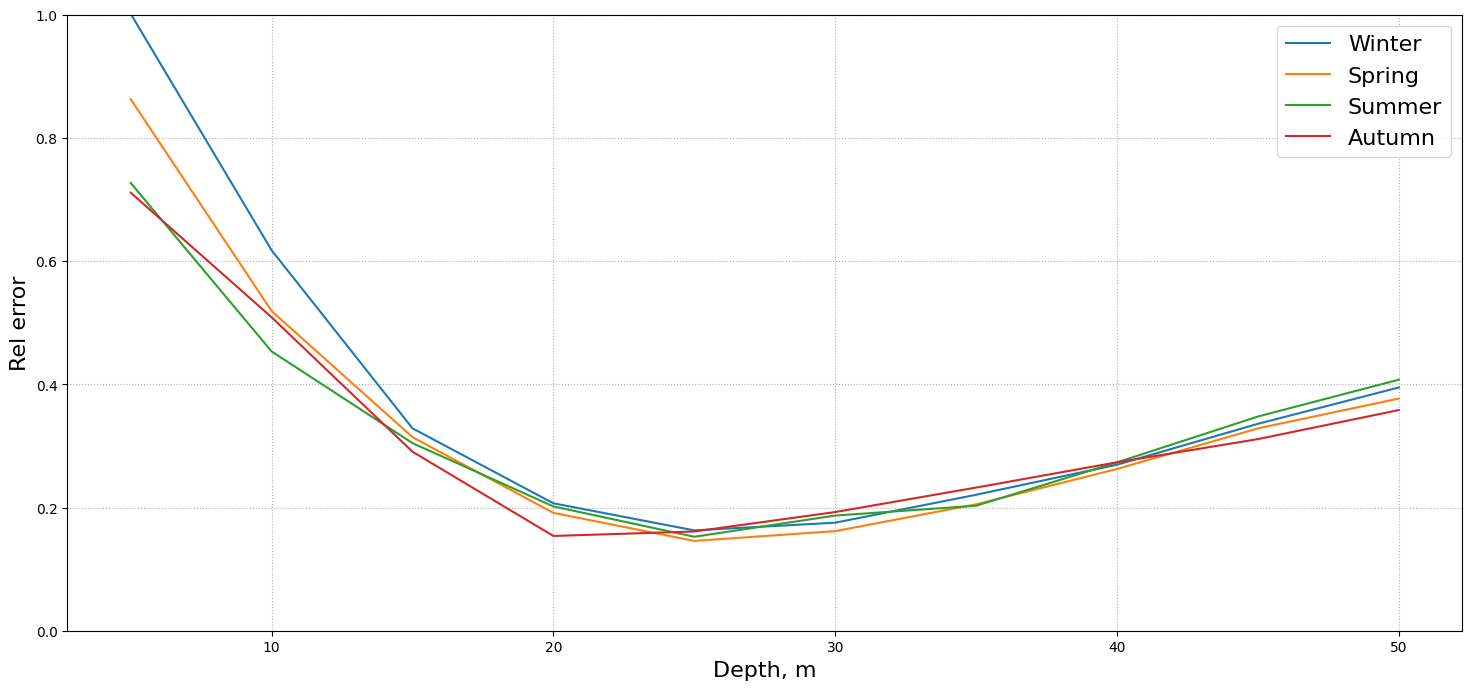

In [76]:
plt.figure(figsize=(18, 8))
plt.grid(ls=':')
for track in zs_all.keys():
    plt.plot(np.linspace(5, 50, 10), rel_by_z[track], label=seasons[track[:2]])
plt.xlabel('Depth, m', fontsize=16)
plt.ylabel('Rel error', fontsize=16)
plt.ylim((0, 1))
plt.legend(fontsize=16)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

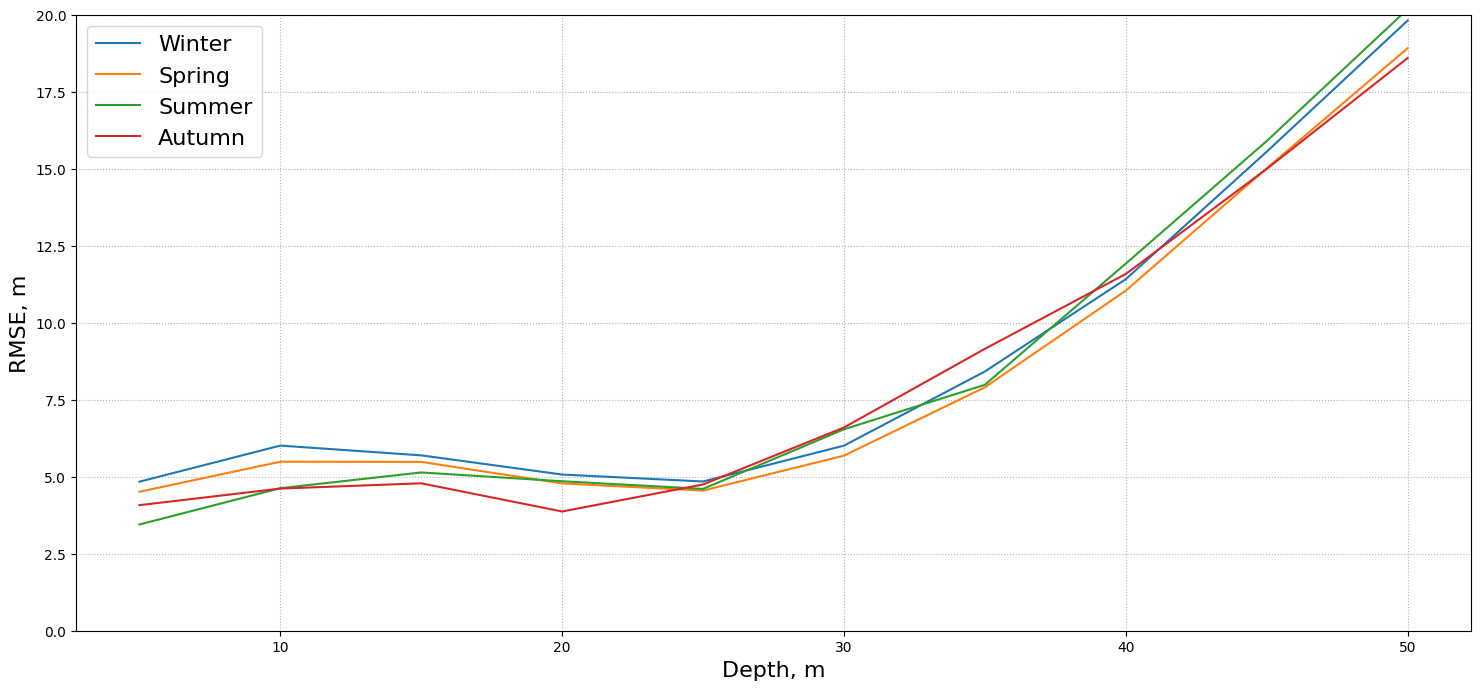

In [77]:
plt.figure(figsize=(18, 8))
plt.grid(ls=':')
for track in zs_all.keys():
    plt.plot(np.linspace(5, 50, 10), rmse_by_z[track], label=seasons[track[:2]])
plt.xlabel('Depth, m', fontsize=16)
plt.ylabel('RMSE, m', fontsize=16)
plt.ylim((0, 20))
plt.legend(fontsize=16)
plt.show

In [78]:
print('RMSE of old model:', np.mean(rmses_old))
print('RMSE of new model:', np.mean(rmses_new))
print('Rel error of old model:', np.mean(rels_old))
print('Rel error of new model:', np.mean(rels_new))

RMSE of old model: nan
RMSE of new model: 6.8115110859184185
Rel error of old model: nan
Rel error of new model: 0.3314497626587978


/home/docker_opr_ros2/.local/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/docker_opr_ros2/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


#### Визуализация

In [79]:
from typing import Tuple

def project_points_to_camera(
    points: np.ndarray, proj_matrix: np.ndarray, cam_res: Tuple[int, int]
) -> Tuple[np.ndarray, np.ndarray]:
    if points.shape[0] == 3:
        points = np.vstack((points, np.ones((1, points.shape[1]))))
    if len(points.shape) != 2 or points.shape[0] != 4:
        raise ValueError(
            f"Wrong shape of points array: {points.shape}; expected: (4, n), where n - number of points."
        )
    if proj_matrix.shape != (3, 4):
        raise ValueError(f"Wrong proj_matrix shape: {proj_matrix}; expected: (3, 4).")
    in_image = points[2, :] > 0
    depths = points[2, in_image]
    uvw = np.dot(proj_matrix, points[:, in_image])
    uv = uvw[:2, :]
    w = uvw[2, :]
    uv[0, :] /= w
    uv[1, :] /= w
    in_image = (uv[0, :] >= 0) * (uv[0, :] < cam_res[0]) * (uv[1, :] >= 0) * (uv[1, :] < cam_res[1])
    return uv[:, in_image].astype(int), depths[in_image]

In [80]:
def depths_to_colors(depths: np.ndarray, max_depth: int = 10, cmap: str = "hsv") -> np.ndarray:
    depths /= max_depth
    to_colormap = plt.get_cmap(cmap)
    rgba_values = to_colormap(depths, bytes=True)
    return rgba_values[:, :3].astype(int)

In [81]:
from cv2 import resize
%timeit resize(test_img, (480, 640))

171 μs ± 767 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [82]:
image_resized = resize(test_img, (640, 480))
image_resized.max()

255

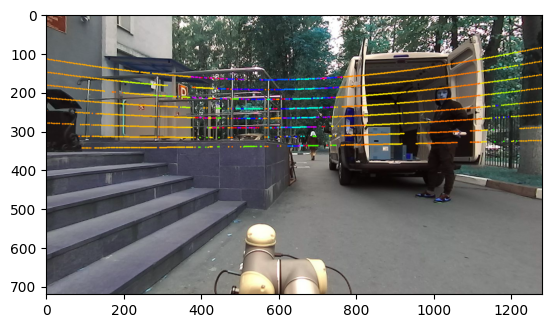

In [83]:
cloud_expanded = np.hstack([test_cloud, np.ones((test_cloud.shape[0], 1))])
b = tf_matrix.T @ cloud_expanded.T
b = b.T[b.T[:, 1] < 0].T
uv, depths = project_points_to_camera(b, proj_matrix, (1280, 720))
rgb_distances = depths_to_colors(depths, max_depth=50)
for point, d in zip(uv.T, rgb_distances):
    c = (int(d[0]), int(d[1]), int(d[2]))
    cv2.circle(test_img, point, radius=2, color=c, thickness=cv2.FILLED)
plt.imshow(test_img)

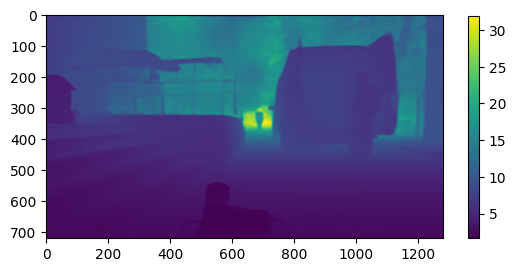

In [84]:
plt.imshow(depth)
plt.colorbar(shrink=0.6)

#### Создание облака точек по восстановленной глубине методом обратной проекции

In [85]:
h, w = depth.shape
def get_point_cloud_from_depth(depth, f, cx, cy):
    print(depth.shape, f, cx, cy)
    i = np.tile(np.arange(h), w).reshape((w, h)).T
    j = np.tile(np.arange(w), h).reshape((h, w))
    z = depth.ravel()
    x = (j.ravel() - cx) / f * z
    y = (i.ravel() - cy) / f * z
    pcd = np.zeros((x.shape[0], 3))
    pcd[:, 0] = x
    pcd[:, 1] = y
    pcd[:, 2] = z
    return pcd

pcd = get_point_cloud_from_depth(depth, camera_matrix['f'], camera_matrix['cx'], camera_matrix['cy'])

(720, 1280) 683.6 615.1 345.3


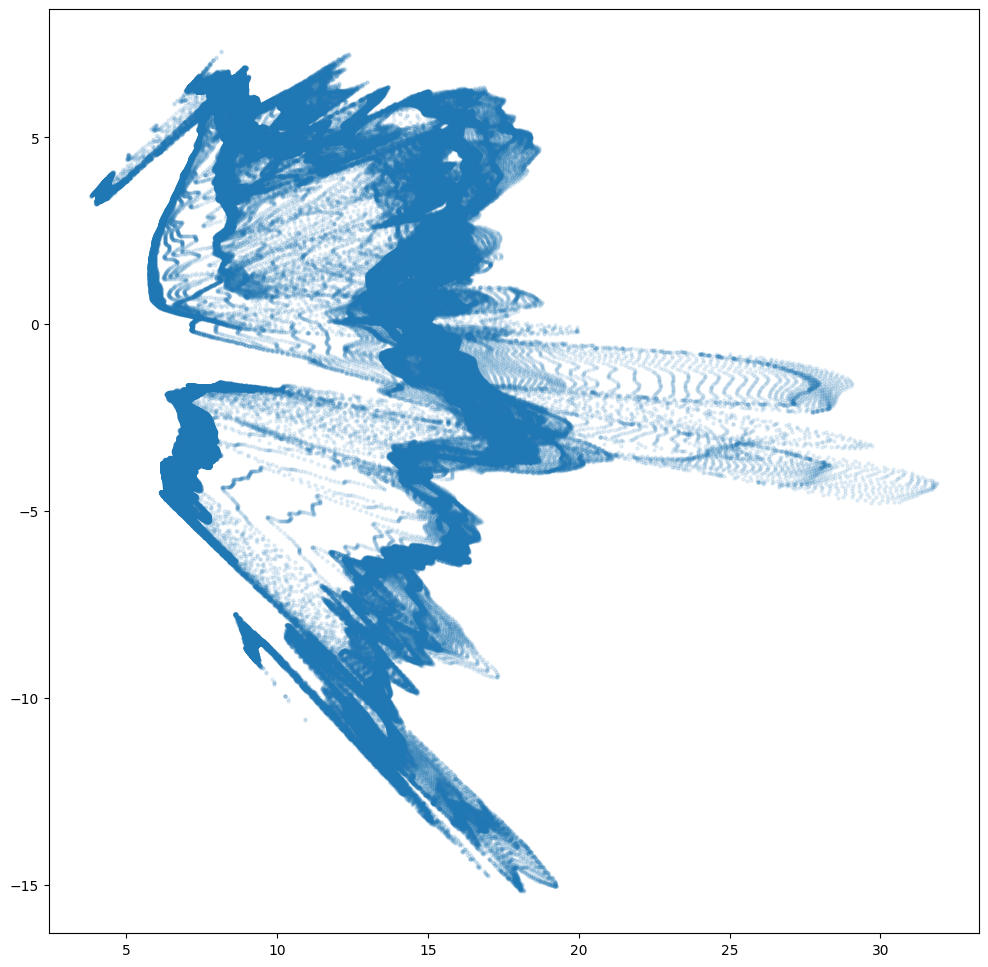

In [86]:
plt.figure(figsize=(12, 12))
plt.scatter(pcd[:, 2][pcd[:, 1] < 0.], -pcd[:, 0][pcd[:, 1] < 0.], s=5, alpha=0.1)
plt.show()

#### Сравнение восстановленного и лидарного облака

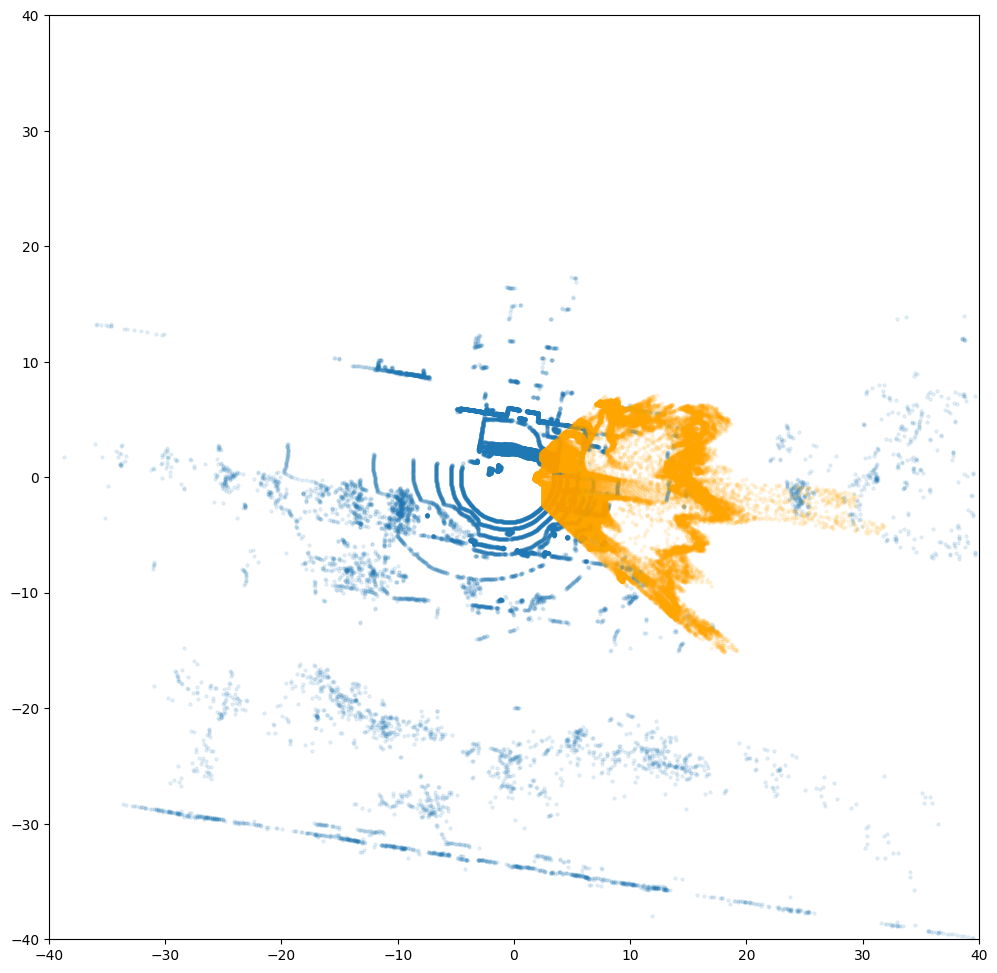

In [87]:
plt.figure(figsize=(12, 12))
plt.xlim((-40, 40))
plt.ylim((-40, 40))
plt.scatter(test_cloud[:, 0], test_cloud[:, 1], s=5, alpha=0.1)
#plt.scatter(test_cloud[:, 0][test_cloud[:, 2] > 0], test_cloud[:, 1][test_cloud[:, 2] > 0], s=5, alpha=0.1)
plt.scatter(pcd[::17, 2], -pcd[::17, 0], color='orange', s=5, alpha=0.1)
plt.show()